# Setup

In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from astropy import constants as const, units as u

In [2]:
import sys
sys.path.append('../')

In [3]:
from functions import epsilon

In [4]:
plt.rcParams['font.family']      = 'serif'
plt.rcParams['font.serif']       = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'  # <--- default: dejavusans

/var/folders/66/47rx8tnd05173x195n9trmvr0000gp/T/ipykernel_5111/3807331744.py:81: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x3353192e0>' will be ignored
  ax0contourf.set_rasterized(True)
/var/folders/66/47rx8tnd05173x195n9trmvr0000gp/T/ipykernel_5111/3807331744.py:82: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x13783c7d0>' will be ignored
  ax1contourf.set_rasterized(True)


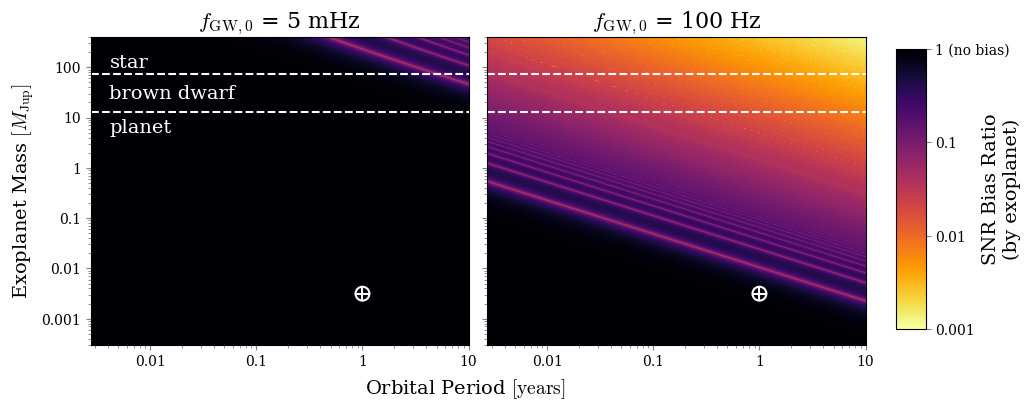

In [70]:
fig, ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.05)#, hspace=0)
ax[0].set_xscale('log'), ax[0].set_yscale('log')


i = np.pi/2

Pvals = np.logspace(np.log10(1*u.day.to(u.year)),np.log10(10),1000)  # units: [years]
Mvals = np.logspace(np.log10(0.0003),np.log10(400),1000)             # units: [Jup mass]
PPvals, MMvals = np.meshgrid(Pvals, Mvals)

level_exp = np.linspace(np.log10(1e-3), 0, 400)
levels    = np.power(10, level_exp)

colormap = 'inferno_r' #'inferno_r'

# 1st panel  ----------------------------------------------------------------------------------------------------------------------------
M_sys = 1.5 * const.M_sun.value
f_gw0 = 5e-3

epsvals_0 = epsilon( MMvals*const.M_jup.value, i, 1/(PPvals*u.year.to(u.s)), f_gw0, M_sys )
Ratio_0   = np.abs(sp.jv(0,epsvals_0))

ax0contourf = ax[0].contourf(PPvals, MMvals, Ratio_0, levels, norm=colors.LogNorm(), cmap=colormap)
ax[0].set_title(r'$f_\mathrm{{GW,0}}$ = {0:0.0f} mHz'.format(f_gw0/1e-3), fontsize=16)



# 2nd panel  ----------------------------------------------------------------------------------------------------------------------------
M_sys = 1.5 * const.M_sun.value
f_gw0 = 1e2

epsvals_1 = epsilon( (MMvals)*const.M_jup.value, i, 1/((PPvals)*u.year.to(u.s)), f_gw0, M_sys )
Ratio_1   = np.abs(sp.jv(0,epsvals_1))

ax1contourf = ax[1].contourf(PPvals, MMvals, Ratio_1, levels, norm=colors.LogNorm(), cmap=colormap)
ax[1].set_title(r'$f_\mathrm{{GW,0}}$ = {0:0.0f} Hz'.format(f_gw0), fontsize=16)


# Colorbar  ----------------------------------------------------------------------------------------------------------------------------
cbar_ax = fig.add_axes([0.93, 0.15, 0.03, 0.7])
cbar = fig.colorbar(ax1contourf, cax=cbar_ax, ticks=np.array([0.001,0.01,0.1,1]))
cbar.set_label(r'SNR Bias Ratio'+'\n'+r'(by exoplanet)', fontsize=14, labelpad=-20)
cbar.ax.tick_params(color='grey')
cbar.ax.set_yticklabels(['0.001','0.01', '0.1', '1 (no bias)'])


# Reference Planets  -------------------------------------------------------------------------------------------------------------------
for i in range(0,len(ax)):
    # -- Jupiter
    # ax[i].scatter(11.86,1, marker='o')
    # -- Earth
    ax[i].scatter(1,1*u.M_earth.to(u.M_jup), marker='o', facecolor='none', linewidths=1.5, edgecolor='white', s=100)  
    ax[i].scatter(1,1*u.M_earth.to(u.M_jup), marker='+', color='white', s=100)



# Text and horizontal lines ---------------------------------------------------------------------------------------------------------------
for i in range(0,len(ax)):
    ax[i].axhline(13, linestyle='--', color='white')
    ax[i].axhline(72, linestyle='--', color='white')
    if i == 0:
        ax[i].text(0.05,13-8,  'planet',      fontsize=14, color='white', transform=ax[i].get_yaxis_transform())
        ax[i].text(0.05,13+11, 'brown dwarf', fontsize=14, color='white', transform=ax[i].get_yaxis_transform())
        ax[i].text(0.05,72+26, 'star',        fontsize=14, color='white', transform=ax[i].get_yaxis_transform())

# # Text and vertical lines ---------------------------------------------------------------------------------------------------------------
# ax[0].axvline(4/2, linestyle='--', color='gray')
# ax[1].axvline(0.8333/2, linestyle='--', color='gray')

# Axes labels and titles formatting  ------------------------------------------------------------------------------------------------------
ax[0].set_xticks([1e-2,1e-1,1,1e1]), ax[0].set_xticklabels(['0.01', '0.1', '1', '10'])
fig.supxlabel(r'Orbital Period $[\text{years}]$', y=-0.03, fontsize=14)

ax[0].set_yticks([1e-3,1e-2,1e-1,1,1e1,1e2]), ax[0].set_yticklabels(['0.001','0.01', '0.1', '1', '10', '100']) #$\\mathdefault{10^{-3}}$
ax[0].set_ylabel(r'Exoplanet Mass $[M_\text{Jup}]$', fontsize=14)
ax[0].tick_params(axis='both', which='both', color='gray'), ax[1].tick_params(axis='both', which='both', color='gray')

# Rasterize the contourfs, to reduce the PDF file size significantly!
# NOTE: it may output a "UserWarning" - I don't know why, but this line still works (verified by opening the file in Inkscape)
ax0contourf.set_rasterized(True)
ax1contourf.set_rasterized(True)

plt.show()
# plt.savefig('./bias_ratio.pdf', bbox_inches='tight')

In [79]:
rtol = 1e-4
RRvals = Ratio_1
inds_tuple = np.where(np.isclose(RRvals, 0.001, rtol=rtol))

print("P       M       B")
for i in range(0,len(inds_tuple[0])):
    a, b = inds_tuple[0][i], inds_tuple[1][i]
    print(f"{PPvals[a,b]:0.2f}, {MMvals[a,b]:0.2f}, {RRvals[a,b]:0.4f}")

P       M       B
1.14, 0.30, 0.0010
0.02, 2.59, 0.0010
1.74, 100.28, 0.0010
1.81, 157.55, 0.0010
